# Regresión lineal para predicción de progresión de diabetes
- age: Representa la edad del paciente, normalizada (no es la edad real, sino una representación estandarizada).
- sex: Sexo del paciente, representado como una variable numérica normalizada (valores entre -0.5 y 0.5).
- bmi: Índice de Masa Corporal (Body Mass Index, BMI), una medida del peso relativo al cuadrado de la altura.
- bp:
Promedio de presión arterial (Blood Pressure, BP), normalizada.
- s1: Nivel sérico de lípidos totales (colesterol total).
- s2: Nivel sérico de lipoproteínas de baja densidad (LDL, “colesterol malo”).
- s3: Nivel sérico de lipoproteínas de alta densidad (HDL, “colesterol bueno”).
- s4: Relación entre el colesterol total y HDL.
- s5: Nivel sérico de triglicéridos, representado como una medida numérica normalizada.
- s6: Nivel sérico de glucosa en ayuno, una medida clave en el monitoreo de la diabetes.

## Fundamentos de la regresión lineal

La **regresión lineal** es un método estadístico supervisado que modela la relación entre una variable objetivo continua y una o más variables predictoras.

### Modelo matemático
- **Regresión lineal simple:**  \( y = \beta_0 + \beta_1 x + \varepsilon \)
- **Regresión lineal múltiple:**  \( y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \varepsilon \)

Donde:
- \( y \) es la variable objetivo.
- \( \beta_0 \) es el intercepto.
- \( \beta_i \) son los coeficientes que miden el efecto de cada variable.
- \( \varepsilon \) es el error aleatorio.

### Idea principal
El modelo busca la recta o hiperplano que **minimiza la suma de los errores al cuadrado**, es decir:

\[
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
\]

### Diferencias clave
- La **regresión lineal simple** usa una sola variable predictora.
- La **regresión lineal múltiple** usa varias variables predictoras.
- La múltiple suele capturar mejor el problema, pero también puede ser más difícil de interpretar.

### Métricas de evaluación
- **MSE:** penaliza más los errores grandes.
- **RMSE:** raíz del MSE, en las mismas unidades del objetivo.
- **R²:** indica qué proporción de la variabilidad logra explicar el modelo.

In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Cargar el conjunto de datos
diabetes_data = load_diabetes()

# Convertir el conjunto de datos a un DataFrame para facilitar su manipulación
df = pd.DataFrame(data=diabetes_data.data, columns=diabetes_data.feature_names)
df['target'] = diabetes_data.target  # Agregar la variable objetivo al DataFrame

# Mostrar las primeras filas del DataFrame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Primeras filas del conjunto de datos:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Resumen estadístico:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000



Comparación de métricas:


,Modelo,MSE,RMSE,R²
0,Regresión lineal simple (bmi),4061.825928,63.732456,0.233350
1,Regresión lineal múltiple,2900.193628,53.853446,0.452603



Coeficientes del modelo múltiple:


,Variable,Coeficiente
4,s1,-931.488846
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
1,sex,-241.964362
6,s3,163.419983
9,s6,48.670657
0,age,37.904021


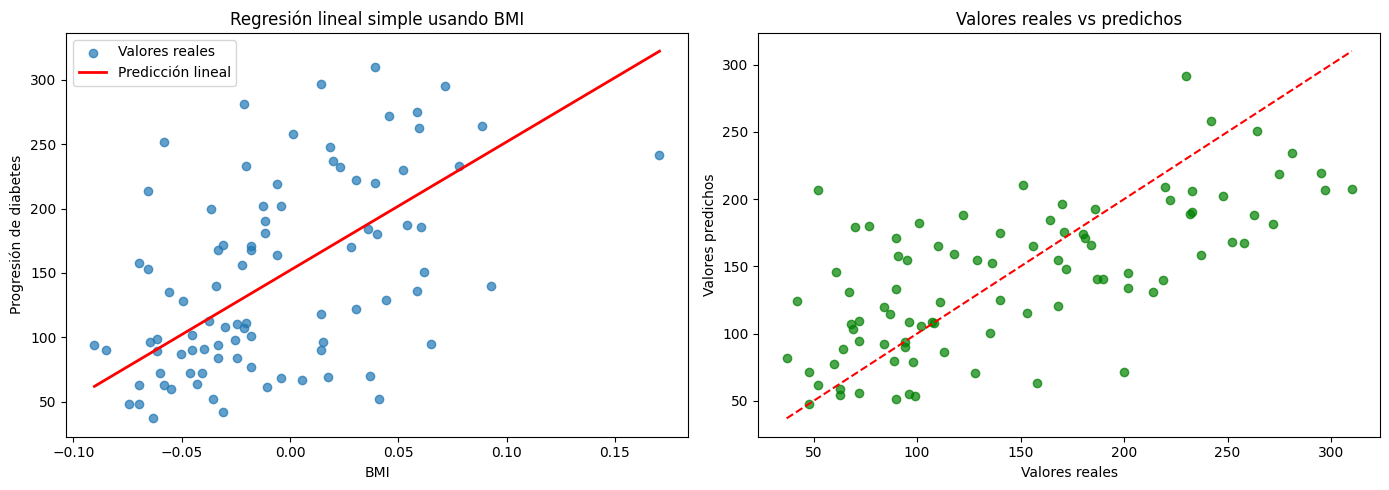


Conclusión:
El modelo de regresión lineal múltiple presenta mejor desempeño porque obtiene un MSE menor y explica mejor la variabilidad de los datos.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Variable objetivo
y = df['target']

# -----------------------------
# 1. Regresión lineal simple
# -----------------------------
X_simple = df[['bmi']]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train_s)
y_pred_simple = modelo_simple.predict(X_test_s)

mse_simple = mean_squared_error(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

# -----------------------------
# 2. Regresión lineal múltiple
# -----------------------------
X_multiple = df.drop(columns='target')
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_m, y_train_m)
y_pred_multiple = modelo_multiple.predict(X_test_m)

mse_multiple = mean_squared_error(y_test_m, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test_m, y_pred_multiple)

# -----------------------------
# Comparación de resultados
# -----------------------------
comparacion = pd.DataFrame({
    'Modelo': ['Regresión lineal simple (bmi)', 'Regresión lineal múltiple'],
    'MSE': [mse_simple, mse_multiple],
    'RMSE': [rmse_simple, rmse_multiple],
    'R²': [r2_simple, r2_multiple]
})

print('Primeras filas del conjunto de datos:')
display(df.head())

print('\nResumen estadístico:')
display(df.describe())

print('\nComparación de métricas:')
display(comparacion)

print('\nCoeficientes del modelo múltiple:')
coeficientes = pd.DataFrame({
    'Variable': X_multiple.columns,
    'Coeficiente': modelo_multiple.coef_
}).sort_values(by='Coeficiente', key=lambda s: abs(s), ascending=False)
display(coeficientes)

# -----------------------------
# Visualización
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del modelo simple
axes[0].scatter(X_test_s['bmi'], y_test_s, alpha=0.7, label='Valores reales')
orden = np.argsort(X_test_s['bmi'].to_numpy())
axes[0].plot(
    X_test_s['bmi'].to_numpy()[orden],
    y_pred_simple[orden],
    color='red',
    linewidth=2,
    label='Predicción lineal'
)
axes[0].set_title('Regresión lineal simple usando BMI')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Progresión de diabetes')
axes[0].legend()

# Gráfico del modelo múltiple
axes[1].scatter(y_test_m, y_pred_multiple, alpha=0.7, color='green')
min_val = min(y_test_m.min(), y_pred_multiple.min())
max_val = max(y_test_m.max(), y_pred_multiple.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[1].set_title('Valores reales vs predichos')
axes[1].set_xlabel('Valores reales')
axes[1].set_ylabel('Valores predichos')

plt.tight_layout()
plt.show()

print('\nConclusión:')
if mse_multiple < mse_simple:
    print('El modelo de regresión lineal múltiple presenta mejor desempeño porque obtiene un MSE menor y explica mejor la variabilidad de los datos.')
else:
    print('El modelo simple presenta un desempeño similar o mejor en este conjunto de datos.')